# 🎯 ML Model Comparison — Seasonal Demand Forecaster
## AI-Based Seasonal Demand Forecaster & Inventory Decision Support System
**S6 MiniProject · March 2026**

This notebook covers:
1. **Exploratory Data Analysis** — Rossmann dataset patterns
2. **Model Performance Comparison** — RF vs XGBoost across all 5 tasks
3. **Feature Importance** — what drives demand
4. **Confusion Matrices** — classifier quality
5. **Time Series** — actual vs predicted with festival peaks
6. **Architecture Diagram** — full system pipeline

> Run cells top-to-bottom. All outputs save to `outputs/evaluation/`.

In [12]:
# ── Imports & Setup ───────────────────────────────────────────────────────────
import os, sys, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc
)
from xgboost import XGBRegressor, XGBClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Paths
BASE_DIR  = os.getcwd()
DATA_DIR  = os.path.join(BASE_DIR, "Data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
OUT_DIR   = os.path.join(BASE_DIR, "outputs")
EVAL_DIR  = os.path.join(OUT_DIR,  "evaluation")
os.makedirs(EVAL_DIR, exist_ok=True)

PALETTE = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63", "#9C27B0"]
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.titleweight": "bold"})

print("✅ Libraries loaded")
print(f"   BASE_DIR  : {BASE_DIR}")
print(f"   models/   : {os.listdir(MODEL_DIR) if os.path.exists(MODEL_DIR) else 'NOT FOUND'}")

✅ Libraries loaded
   BASE_DIR  : S:\Pnav College\S6\MiniProject\Seasonal Demand Forecaster
   models/   : ['demand_rf.pkl', 'demand_xgb.pkl', 'discount_xgb.pkl', 'festival_uplift_xgb.pkl', 'inventory_priority_xgb.pkl', 'inventory_rf.pkl', 'le_assortment.pkl', 'le_discount_tier.pkl', 'le_inventory_action.pkl', 'le_region_discount.pkl', 'le_store_type.pkl', 'stockout_xgb.pkl']


---
## Section 1 — Exploratory Data Analysis

Understanding the Rossmann dataset that we trained on: 1,017,211 rows, 1,116 stores.

In [13]:
# ── EDA: Load Rossmann dataset ────────────────────────────────────────────────
train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
store = pd.read_csv(os.path.join(DATA_DIR, "store.csv"))
df_raw = train.merge(store, on="Store", how="left")
df_raw["Date"] = pd.to_datetime(df_raw["Date"])
df = df_raw[(df_raw["Open"] == 1) & (df_raw["Sales"] > 0)].copy()
df["Month"]      = df["Date"].dt.month
df["Year"]       = df["Date"].dt.year
df["WeekOfYear"] = df["Date"].dt.isocalendar()["week"].astype(int)
df["IsHoliday"]  = df["StateHoliday"].astype(str).apply(lambda x: 0 if x == "0" else 1)

print(f"Dataset: {len(df):,} rows  |  {df['Store'].nunique()} stores  |  {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"\nTarget — Sales stats:")
print(df["Sales"].describe().to_string())

Dataset: 844,338 rows  |  1115 stores  |  2013-01-01 → 2015-07-31

Target — Sales stats:
count    844338.000000
mean       6955.959134
std        3103.815515
min          46.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000


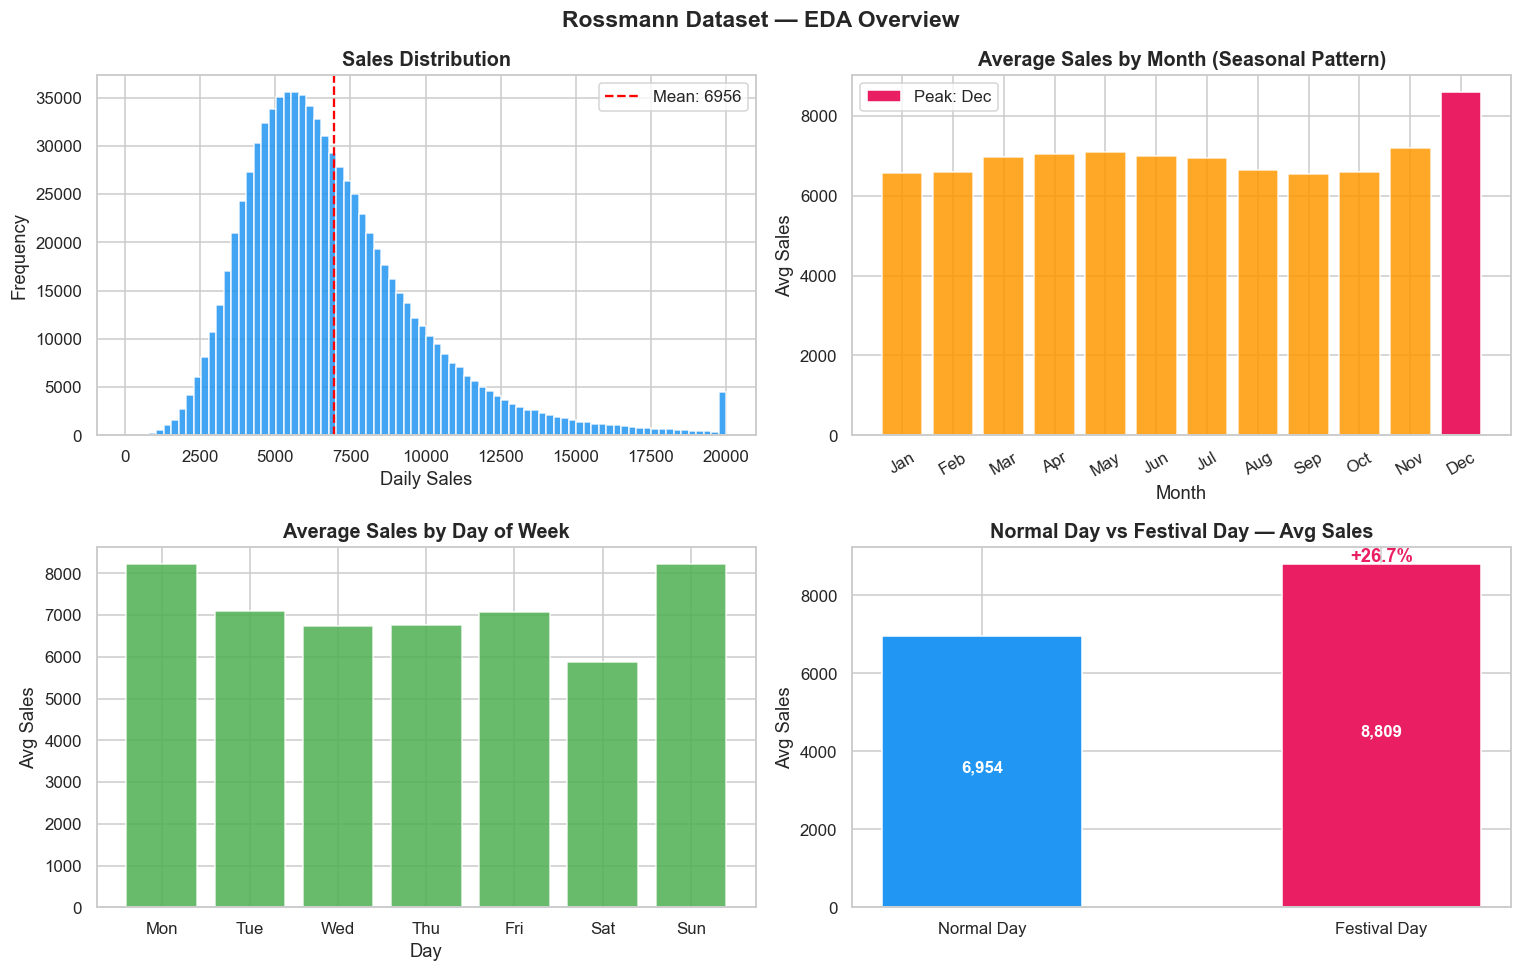

Saved → 00_eda_overview.png


In [14]:
# ── EDA: 4-panel overview chart ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Rossmann Dataset — EDA Overview", fontsize=15, fontweight="bold")

# 1. Sales distribution
ax = axes[0, 0]
ax.hist(df["Sales"].clip(0, 20000), bins=80, color=PALETTE[0], edgecolor="white", alpha=0.85)
ax.set_title("Sales Distribution")
ax.set_xlabel("Daily Sales"); ax.set_ylabel("Frequency")
ax.axvline(df["Sales"].mean(), color="red", linestyle="--", label=f"Mean: {df['Sales'].mean():.0f}")
ax.legend()

# 2. Monthly average sales
monthly = df.groupby("Month")["Sales"].mean()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ax = axes[0, 1]
bars = ax.bar(monthly.index, monthly.values, color=PALETTE[1], edgecolor="white", alpha=0.85)
ax.set_title("Average Sales by Month (Seasonal Pattern)")
ax.set_xlabel("Month"); ax.set_ylabel("Avg Sales")
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_labels, rotation=30)
peak = monthly.idxmax()
ax.bar(peak, monthly[peak], color="#E91E63", label=f"Peak: {month_labels[peak-1]}")
ax.legend()

# 3. DayOfWeek vs Sales
dow = df.groupby("DayOfWeek")["Sales"].mean()
dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
ax = axes[1, 0]
ax.bar(dow.index, dow.values, color=PALETTE[2], edgecolor="white", alpha=0.85)
ax.set_title("Average Sales by Day of Week")
ax.set_xlabel("Day"); ax.set_ylabel("Avg Sales")
ax.set_xticks(range(1,8)); ax.set_xticklabels(dow_labels)

# 4. Holiday effect
holiday_sales   = df[df["IsHoliday"] == 1]["Sales"].mean()
noholiday_sales = df[df["IsHoliday"] == 0]["Sales"].mean()
ax = axes[1, 1]
bars = ax.bar(["Normal Day", "Festival Day"], [noholiday_sales, holiday_sales],
              color=[PALETTE[0], "#E91E63"], edgecolor="white", width=0.5)
ax.set_title("Normal Day vs Festival Day — Avg Sales")
ax.set_ylabel("Avg Sales")
uplift_pct = (holiday_sales / noholiday_sales - 1) * 100
ax.text(1, holiday_sales + 50, f"+{uplift_pct:.1f}%", ha="center", fontsize=12,
        fontweight="bold", color="#E91E63")
for bar, v in zip(bars, [noholiday_sales, holiday_sales]):
    ax.text(bar.get_x()+bar.get_width()/2, v/2, f"{v:,.0f}",
            ha="center", fontsize=11, fontweight="bold", color="white")

plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, "00_eda_overview.png"), bbox_inches="tight")
plt.show()
print("Saved → 00_eda_overview.png")

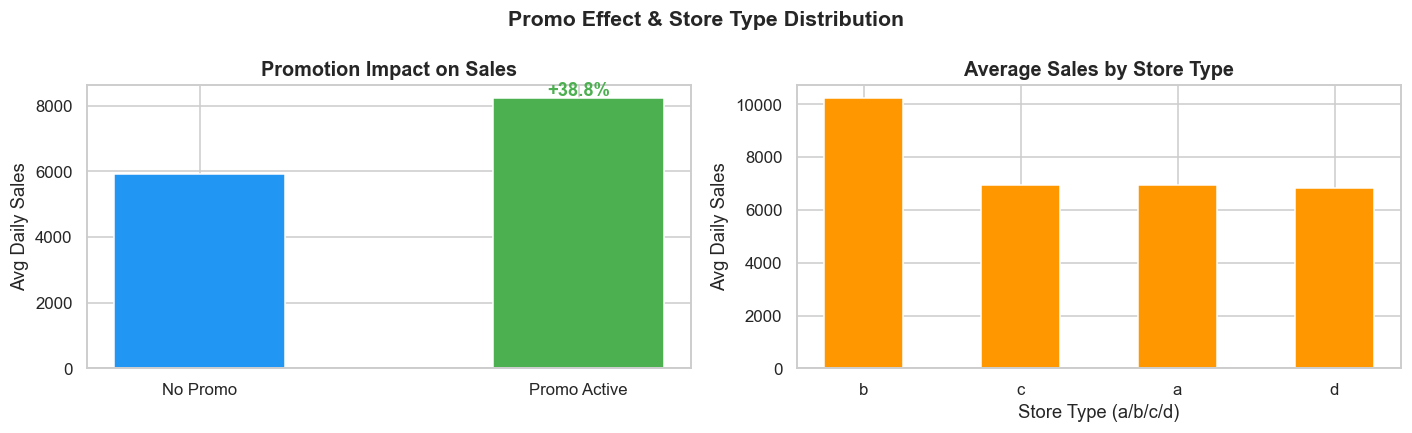

In [15]:
# ── EDA: Promo impact + Store type distribution ───────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Promo Effect & Store Type Distribution", fontsize=14, fontweight="bold")

# Promo effect
promo_sales    = df[df["Promo"]==1]["Sales"].mean()
nopromo_sales  = df[df["Promo"]==0]["Sales"].mean()
ax1.bar(["No Promo","Promo Active"], [nopromo_sales, promo_sales],
        color=[PALETTE[0], PALETTE[2]], edgecolor="white", width=0.45)
ax1.set_title("Promotion Impact on Sales"); ax1.set_ylabel("Avg Daily Sales")
pct = (promo_sales/nopromo_sales - 1)*100
ax1.text(1, promo_sales + 80, f"+{pct:.1f}%", ha="center", fontsize=12,
         fontweight="bold", color=PALETTE[2])

# Store type
st_sales = df.groupby("StoreType")["Sales"].mean().sort_values(ascending=False)
ax2.bar(st_sales.index, st_sales.values, color=PALETTE[1], edgecolor="white", width=0.5)
ax2.set_title("Average Sales by Store Type"); ax2.set_ylabel("Avg Daily Sales")
ax2.set_xlabel("Store Type (a/b/c/d)")

plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, "00b_eda_promo_storetype.png"), bbox_inches="tight")
plt.show()

---
## Section 2 — Model 1: Demand Forecasting (RF vs XGBoost)

We train on 85% of the data, evaluate on the held-out 15%.  
Key metric: **R²** (how much variance the model explains) and **MAE** (average error in sales units).

In [16]:
# ── Prepare demand test split (same split as training) ────────────────────────
le_st = joblib.load(os.path.join(MODEL_DIR, "le_store_type.pkl"))
le_as = joblib.load(os.path.join(MODEL_DIR, "le_assortment.pkl"))
df["StoreType_enc"]  = le_st.transform(df["StoreType"].fillna("unknown"))
df["Assortment_enc"] = le_as.transform(df["Assortment"].fillna("unknown"))
df_m = df.fillna(0)

DEMAND_FEATURES = [
    "Store","DayOfWeek","Promo","SchoolHoliday","CompetitionDistance",
    "Promo2","Year","Month","WeekOfYear","StoreType_enc","Assortment_enc"
]
X = df_m[DEMAND_FEATURES]; y = df_m["Sales"]
_, X_test, _, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
print(f"Test set: {len(X_test):,} samples")

# Load models
rf_m  = joblib.load(os.path.join(MODEL_DIR, "demand_rf.pkl"))
xgb_m = joblib.load(os.path.join(MODEL_DIR, "demand_xgb.pkl"))

rf_pred  = rf_m.predict(X_test)
xgb_pred = xgb_m.predict(X_test)
ens_pred = 0.4 * rf_pred + 0.6 * xgb_pred

demand_metrics = {
    "Random Forest": {
        "MAE":  mean_absolute_error(y_test, rf_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, rf_pred)),
        "R2":   r2_score(y_test, rf_pred),
    },
    "XGBoost": {
        "MAE":  mean_absolute_error(y_test, xgb_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, xgb_pred)),
        "R2":   r2_score(y_test, xgb_pred),
    },
    "Ensemble (40RF/60XGB)": {
        "MAE":  mean_absolute_error(y_test, ens_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, ens_pred)),
        "R2":   r2_score(y_test, ens_pred),
    },
}

pd.DataFrame(demand_metrics).T.style.format({
    "MAE": "{:,.0f}", "RMSE": "{:,.0f}", "R2": "{:.4f}"
}).background_gradient(cmap="RdYlGn", subset=["R2"]).highlight_min(
    subset=["MAE","RMSE"], color="#c6efce"
)

Test set: 126,651 samples


,MAE,RMSE,R2
Random Forest,886,"1,296",0.8274
XGBoost,708,"1,016",0.8939
Ensemble (40RF/60XGB),729,"1,053",0.8861


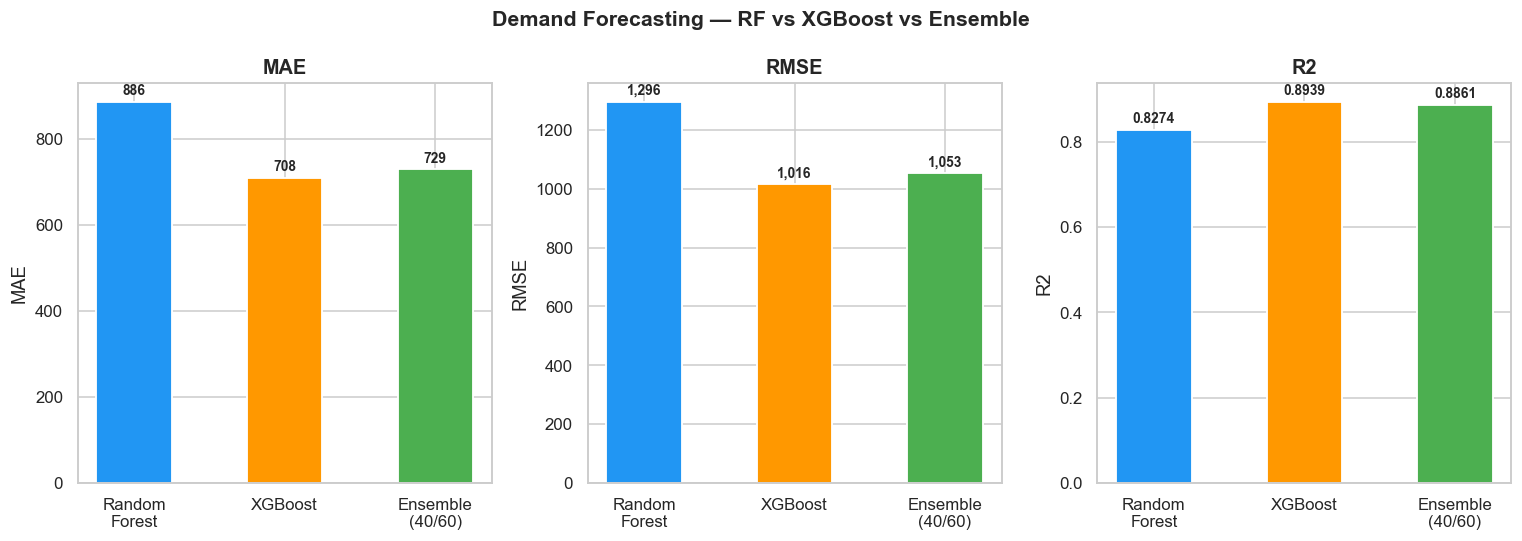

In [17]:
# ── Model comparison bar chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Demand Forecasting — RF vs XGBoost vs Ensemble", fontsize=14, fontweight="bold")
models  = list(demand_metrics.keys())
xlabels = ["Random\nForest", "XGBoost", "Ensemble\n(40/60)"]
colors  = [PALETTE[0], PALETTE[1], PALETTE[2]]

for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    vals = [demand_metrics[m][metric] for m in models]
    bars = ax.bar(xlabels, vals, color=colors, width=0.5, edgecolor="white", linewidth=1.2)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    for bar, v in zip(bars, vals):
        label = f"{v:.4f}" if metric == "R2" else f"{v:,.0f}"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                label, ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, "01_demand_comparison.png"), bbox_inches="tight")
plt.show()

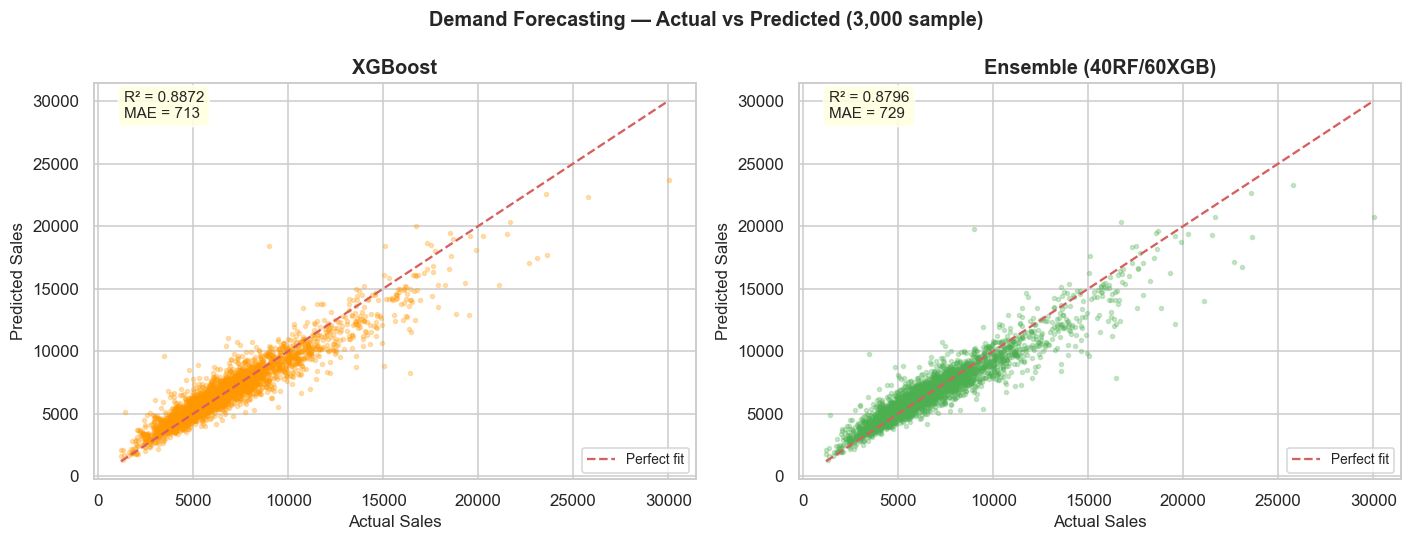

In [18]:
# ── Actual vs Predicted scatter ───────────────────────────────────────────────
idx   = np.random.default_rng(0).choice(len(y_test), size=3000, replace=False)
y_s   = np.array(y_test)[idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Demand Forecasting — Actual vs Predicted (3,000 sample)", fontsize=13, fontweight="bold")

for ax, pred, label, color in [
    (ax1, xgb_pred[idx], "XGBoost", PALETTE[1]),
    (ax2, ens_pred[idx],  "Ensemble (40RF/60XGB)", PALETTE[2]),
]:
    ax.scatter(y_s, pred, alpha=0.28, s=7, color=color)
    lo, hi = min(y_s.min(), pred.min()), max(y_s.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Perfect fit")
    ax.set_xlabel("Actual Sales", fontsize=11)
    ax.set_ylabel("Predicted Sales", fontsize=11)
    ax.set_title(label)
    r2 = r2_score(y_s, pred)
    mae = mean_absolute_error(y_s, pred)
    ax.text(0.05, 0.91, f"R² = {r2:.4f}\nMAE = {mae:,.0f}", transform=ax.transAxes,
            fontsize=10, bbox=dict(boxstyle="round,pad=0.35", facecolor="lightyellow", alpha=0.9))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, "02_demand_scatter.png"), bbox_inches="tight")
plt.show()

---
## Section 3 — Feature Importance Analysis

Which features matter most for demand forecasting?  
Both RF and XGBoost give importance scores — we compare them side-by-side.

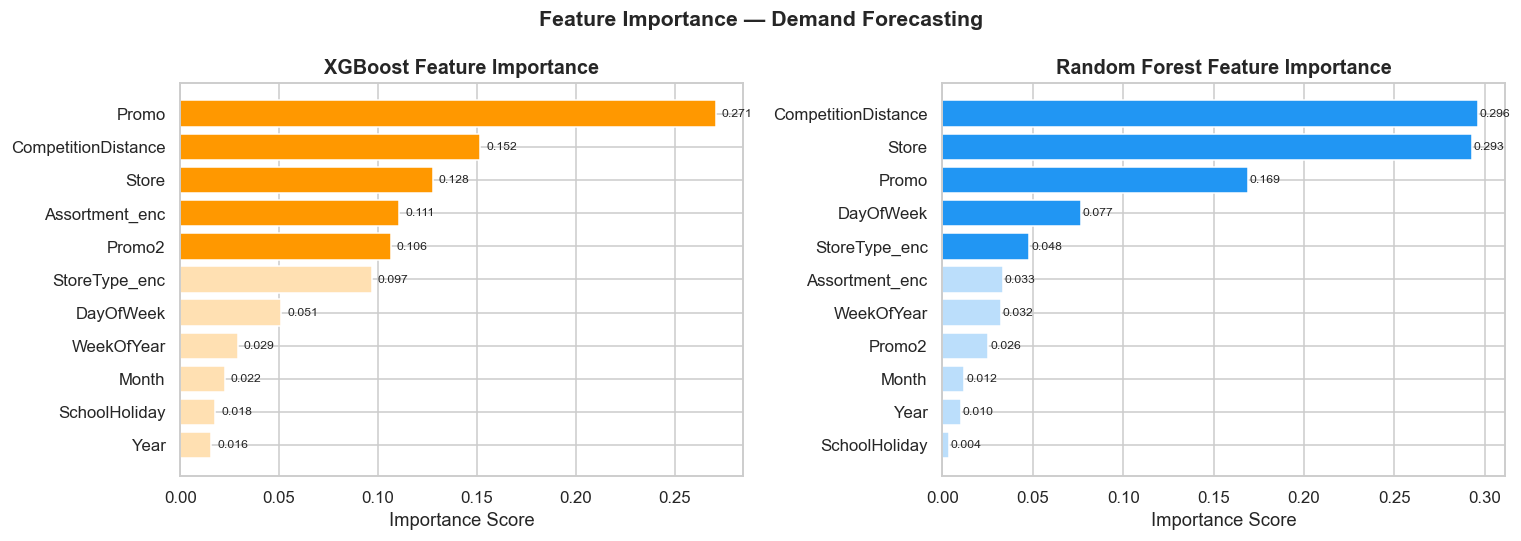

Top 3 XGBoost features: ['Promo', 'CompetitionDistance', 'Store']
Top 3 RF features:      ['CompetitionDistance', 'Store', 'Promo']


In [19]:
# ── Feature Importance: RF vs XGBoost ────────────────────────────────────────
fi_xgb = pd.Series(xgb_m.feature_importances_, index=DEMAND_FEATURES).sort_values()
fi_rf  = pd.Series(rf_m.feature_importances_,  index=DEMAND_FEATURES).sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Feature Importance — Demand Forecasting", fontsize=14, fontweight="bold")

# XGBoost
colors_xgb = [PALETTE[1] if v > fi_xgb.median() else "#FFE0B2" for v in fi_xgb.values]
ax1.barh(fi_xgb.index, fi_xgb.values, color=colors_xgb)
ax1.set_title("XGBoost Feature Importance")
ax1.set_xlabel("Importance Score")
for bar, v in zip(ax1.patches, fi_xgb.values):
    ax1.text(v + 0.003, bar.get_y() + bar.get_height()/2,
             f"{v:.3f}", va="center", fontsize=8)

# Random Forest
colors_rf = [PALETTE[0] if v > fi_rf.median() else "#BBDEFB" for v in fi_rf.values]
ax2.barh(fi_rf.index, fi_rf.values, color=colors_rf)
ax2.set_title("Random Forest Feature Importance")
ax2.set_xlabel("Importance Score")
for bar, v in zip(ax2.patches, fi_rf.values):
    ax2.text(v + 0.001, bar.get_y() + bar.get_height()/2,
             f"{v:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, "03_feature_importance.png"), bbox_inches="tight")
plt.show()

print("Top 3 XGBoost features:", fi_xgb.tail(3).index.tolist()[::-1])
print("Top 3 RF features:     ", fi_rf.tail(3).index.tolist()[::-1])

---
## Section 4 — Classifier Confusion Matrices

Three classifiers in the project:
1. **Discount Tier** (4 classes: NO_DISCOUNT, SMALL_5, MEDIUM_10, HIGH_15)
2. **Inventory Decision** (5 classes: OK → REORDER NOW)
3. **Stockout Risk** (binary: 0 / 1)

In [20]:
# ── Build data for discount classifier test ───────────────────────────────────
sr = pd.read_csv(os.path.join(DATA_DIR, "store_region.csv"))
df_disc = df_m.merge(sr, on="Store", how="left")
df_disc["IsHoliday"] = df_disc["StateHoliday"].astype(str).apply(lambda x: 0 if x == "0" else 1)

agg = df_disc.groupby(["Store","Month","Region"]).agg(
    Avg_Sales=("Sales","mean"), Std_Sales=("Sales","std"),
    Avg_Customers=("Customers","mean"), Promo_Ratio=("Promo","mean"),
    Holiday_Ratio=("IsHoliday","mean"),
).reset_index().fillna(0)
agg = agg.merge(store[["Store","StoreType","Assortment","CompetitionDistance","Promo2"]], on="Store", how="left")

le_st2 = LabelEncoder(); le_as2 = LabelEncoder(); le_rg2 = LabelEncoder()
agg["StoreType_enc"]  = le_st2.fit_transform(agg["StoreType"].fillna("unknown"))
agg["Assortment_enc"] = le_as2.fit_transform(agg["Assortment"].fillna("unknown"))
agg["Region_enc"]     = le_rg2.fit_transform(agg["Region"].fillna("Pan-India"))
agg = agg.fillna(0)

agg["Demand_Score"] = (
    agg["Avg_Sales"] / agg["Avg_Sales"].quantile(0.75) * 0.4 +
    agg["Holiday_Ratio"] * 0.3 +
    agg["Avg_Customers"] / agg["Avg_Customers"].quantile(0.75) * 0.3
)
agg["Discount_Tier"] = np.select(
    [agg["Demand_Score"]>=0.80, agg["Demand_Score"]>=0.60,
     agg["Demand_Score"]>=0.40, agg["Demand_Score"]>=0.20],
    ["NO_DISCOUNT","SMALL_5","MEDIUM_10","HIGH_15"], default="CLEARANCE_20"
)

DISC_FEATURES = [
    "Store","Month","Avg_Sales","Std_Sales","Avg_Customers",
    "Promo_Ratio","Holiday_Ratio","StoreType_enc","Assortment_enc",
    "Region_enc","CompetitionDistance","Promo2"
]
le_tier = joblib.load(os.path.join(MODEL_DIR, "le_discount_tier.pkl"))
disc_model = joblib.load(os.path.join(MODEL_DIR, "discount_xgb.pkl"))
X_d = agg[DISC_FEATURES]; y_d = le_tier.transform(agg["Discount_Tier"])
_, Xd_test, _, yd_test = train_test_split(X_d, y_d, test_size=0.2, random_state=42)
yd_pred = disc_model.predict(Xd_test)
print(f"Discount Classifier Accuracy: {accuracy_score(yd_test, yd_pred):.4f}")

Discount Classifier Accuracy: 0.9873


In [21]:
# ── Build inventory + stockout test data ─────────────────────────────────────
rng = np.random.default_rng(42)
n   = 60000
avg_d  = rng.uniform(50, 2000, n); std_d = avg_d * rng.uniform(0.1, 0.5, n)
safety = 1.65 * std_d * np.sqrt(7); rop = avg_d * 7 + safety
inv_ratio = np.where(rng.random(n) < 0.15, rng.uniform(0.1,0.5,n),
            np.where(rng.random(n) < 0.3,  rng.uniform(0.5,0.7,n),
            np.where(rng.random(n) < 0.5,  rng.uniform(0.7,0.85,n),
            np.where(rng.random(n) < 0.75, rng.uniform(0.85,1.2,n),
            rng.uniform(1.2,2.5,n)))))
cur_inv = rop * inv_ratio; dos = cur_inv / avg_d
fest = rng.choice([0,1], size=n, p=[0.8,0.2])
month = rng.integers(1,13,n); reg = rng.integers(0,6,n); cat = rng.integers(0,10,n)
inv_pos = cur_inv / rop
action = np.where(fest==1,
    np.select([inv_pos>=1.5,inv_pos>=1.0,inv_pos>=0.8,inv_pos>=0.6],
              ["OK","MONITOR","WATCHLIST","REORDER SOON"],"REORDER NOW"),
    np.select([inv_pos>=1.2,inv_pos>=0.85,inv_pos>=0.70,inv_pos>=0.50],
              ["OK","MONITOR","WATCHLIST","REORDER SOON"],"REORDER NOW"))
INV_FEAT = ["Avg_Daily_Demand","Std_Daily_Demand","Current_Inventory","Reorder_Point",
            "Safety_Stock","Days_Of_Supply","Inventory_Position","Festival_Upcoming",
            "Month","Region_enc","Category_enc"]
inv_df = pd.DataFrame(dict(zip(INV_FEAT,
    [avg_d,std_d,cur_inv,rop,safety,dos,inv_pos,fest,month,reg,cat])))
le_act = joblib.load(os.path.join(MODEL_DIR, "le_inventory_action.pkl"))
inv_clf = joblib.load(os.path.join(MODEL_DIR, "inventory_rf.pkl"))
yi = le_act.transform(action)
_, Xi_test, _, yi_test = train_test_split(inv_df, yi, test_size=0.2, random_state=42)
yi_pred = inv_clf.predict(Xi_test)
print(f"Inventory RF Accuracy: {accuracy_score(yi_test, yi_pred):.4f}")

# Stockout data
rng2 = np.random.default_rng(123)
n2 = 60000
avg_d2 = rng2.uniform(50,2000,n2); vol = rng2.uniform(0.1,0.6,n2)
std_d2 = avg_d2 * vol; cur_inv2 = rng2.uniform(0, avg_d2*30)
dos2 = cur_inv2/avg_d2; fest7 = rng2.choice([0,1],size=n2,p=[0.85,0.15])
month2 = rng2.integers(1,13,n2); reg2 = rng2.integers(0,6,n2); cat2 = rng2.integers(0,10,n2)
days_sr = rng2.integers(0,30,n2)
exp_d7 = avg_d2*7*(1.3*fest7 + 1.0*(1-fest7))
actual_d7 = exp_d7 + rng2.normal(0, std_d2*np.sqrt(7), n2)
stockout = (cur_inv2 < actual_d7).astype(int)
SOT_FEAT = ["Current_Inventory","Avg_Daily_Demand","Demand_Volatility","Days_Of_Supply",
            "Lead_Time","Days_Since_Reorder","Festival_In_7d","Month","Region_enc","Category_enc"]
lead = np.full(n2, 7)
sot_df = pd.DataFrame(dict(zip(SOT_FEAT,[cur_inv2,avg_d2,vol,dos2,lead,days_sr,fest7,month2,reg2,cat2])))
sot_model = joblib.load(os.path.join(MODEL_DIR, "stockout_xgb.pkl"))
_, Xs_test, _, ys_test = train_test_split(sot_df, stockout, test_size=0.2, random_state=42)
ys_pred = sot_model.predict(Xs_test)
ys_prob = sot_model.predict_proba(Xs_test)[:,1]
print(f"Stockout XGB Accuracy: {accuracy_score(ys_test, ys_pred):.4f}")

Inventory RF Accuracy: 0.9998
Stockout XGB Accuracy: 0.9719


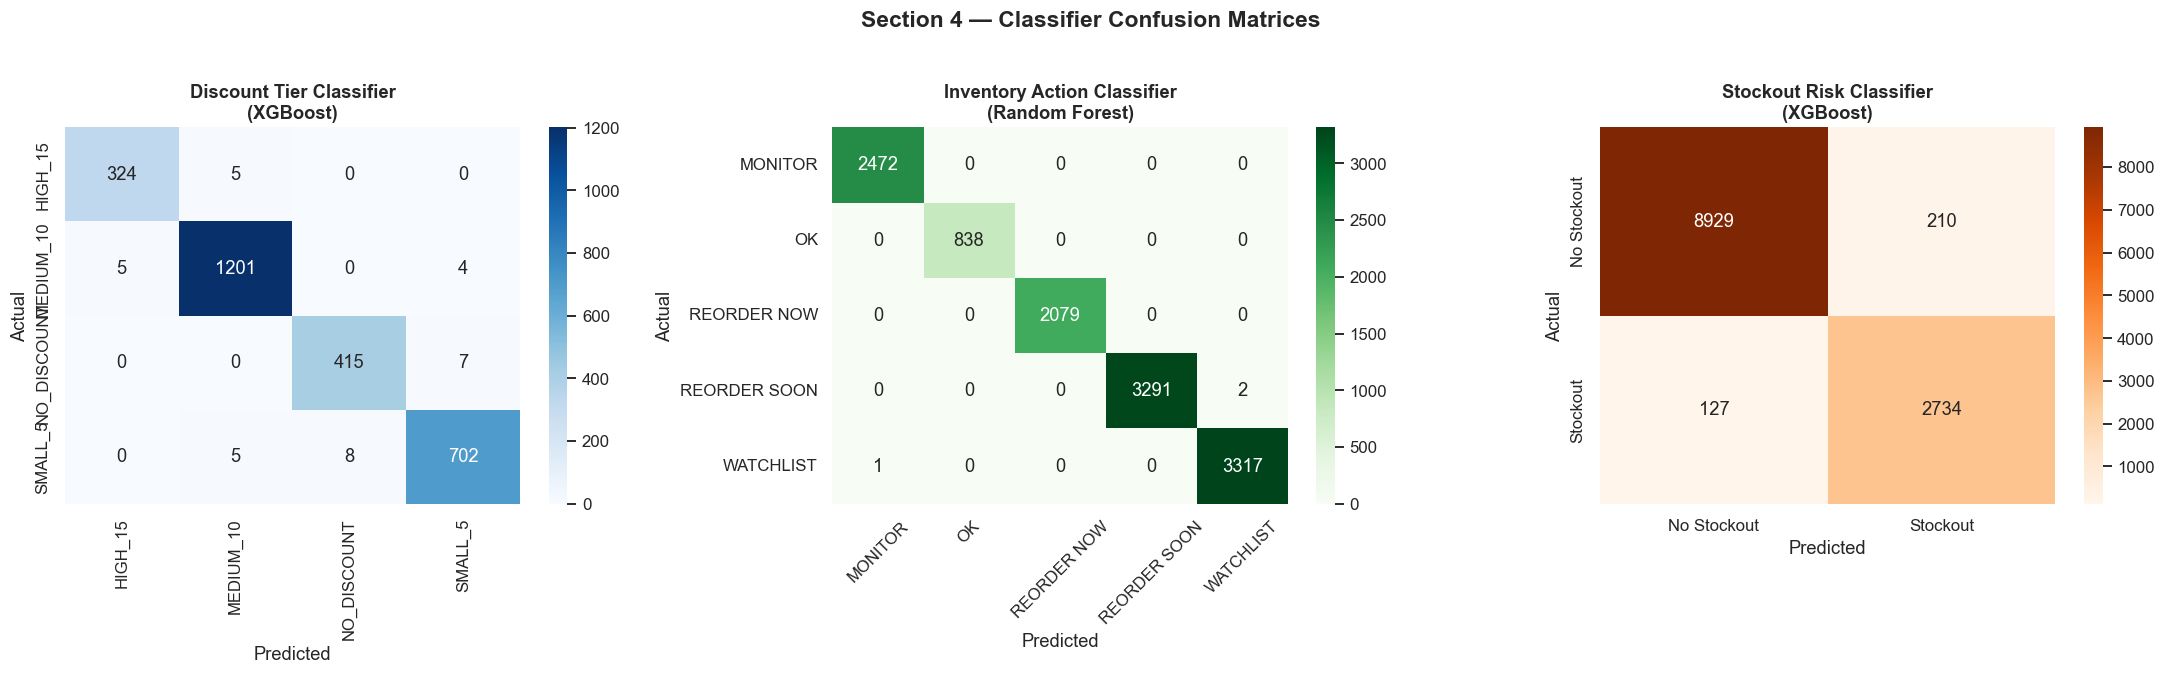

── Discount Classifier ──


NameError: name 'classification_report' is not defined

In [22]:
# ── Confusion matrix grid (Discount, Inventory, Stockout) ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Section 4 — Classifier Confusion Matrices", fontsize=15, fontweight="bold", y=1.02)

# Discount
cm_d = confusion_matrix(yd_test, yd_pred)
sns.heatmap(cm_d, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_tier.classes_, yticklabels=le_tier.classes_, ax=axes[0])
axes[0].set_title("Discount Tier Classifier\n(XGBoost)", fontsize=12)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# Inventory
cm_i = confusion_matrix(yi_test, yi_pred)
labels_i = le_act.classes_
sns.heatmap(cm_i, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels_i, yticklabels=labels_i, ax=axes[1])
axes[1].set_title("Inventory Action Classifier\n(Random Forest)", fontsize=12)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].tick_params(axis='x', rotation=45)

# Stockout
cm_s = confusion_matrix(ys_test, ys_pred)
sns.heatmap(cm_s, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["No Stockout","Stockout"], yticklabels=["No Stockout","Stockout"], ax=axes[2])
axes[2].set_title("Stockout Risk Classifier\n(XGBoost)", fontsize=12)
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")

plt.tight_layout()
os.makedirs(EVAL_DIR, exist_ok=True)
plt.savefig(os.path.join(EVAL_DIR, "confusion_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()

# Classification reports
print("── Discount Classifier ──")
print(classification_report(yd_test, yd_pred, target_names=le_tier.classes_))
print("── Inventory Classifier ──")
print(classification_report(yi_test, yi_pred, target_names=le_act.classes_))
print("── Stockout Classifier ──")
print(classification_report(ys_test, ys_pred, target_names=["No Stockout","Stockout"]))

In [ ]:
# ── ROC Curve — Stockout Classifier ──────────────────────────────────────────
from sklearn.metrics import roc_curve, auc as sk_auc

fpr, tpr, _ = roc_curve(ys_test, ys_prob)
roc_auc = sk_auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr, color="#e74c3c", lw=2, label=f"ROC (AUC = {roc_auc:.4f})")
axes[0].plot([0,1],[0,1],"k--", lw=1)
axes[0].fill_between(fpr, tpr, alpha=0.1, color="#e74c3c")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Stockout Classifier — ROC Curve", fontsize=13, fontweight="bold")
axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)

# Precision-recall curve
from sklearn.metrics import precision_recall_curve
prec, rec, _ = precision_recall_curve(ys_test, ys_prob)
pr_auc = sk_auc(rec, prec)
axes[1].plot(rec, prec, color="#2ecc71", lw=2, label=f"PR AUC = {pr_auc:.4f}")
axes[1].fill_between(rec, prec, alpha=0.1, color="#2ecc71")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Stockout Classifier — Precision-Recall Curve", fontsize=13, fontweight="bold")
axes[1].legend(loc="lower left"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, "roc_pr_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Stockout ROC-AUC: {roc_auc:.4f}  |  PR-AUC: {pr_auc:.4f}")

## Section 5 — Time-Series Forecasting: Baseline vs Festival-Adjusted

This section loads the pipeline's pre-computed yearly forecast and visualises how the ML festival uplift model (XGBRegressor) modifies the baseline demand at key Indian festival periods.

In [ ]:
# ── Time-series: Baseline vs Festival-Adjusted forecast ──────────────────────
ts_path = os.path.join(BASE_DIR, "outputs", "yearly_festival_adjusted_forecast.csv")
fc_path = os.path.join(BASE_DIR, "outputs", "yearly_forecast_indian.csv")

if os.path.exists(ts_path):
    ts = pd.read_csv(ts_path)
    date_col = [c for c in ts.columns if "date" in c.lower() or "week" in c.lower()]
    base_col  = [c for c in ts.columns if "baseline" in c.lower() or "base" in c.lower()]
    fest_col  = [c for c in ts.columns if "festival" in c.lower() or "adjusted" in c.lower() or "uplift" in c.lower()]
    print("Columns:", ts.columns.tolist()); print(ts.head(3))
elif os.path.exists(fc_path):
    ts = pd.read_csv(fc_path)
    print("Columns:", ts.columns.tolist()); print(ts.head(3))
else:
    # Fallback: synthesize from EDA data to show the concept
    months = pd.date_range("2024-01-01", periods=52, freq="W")
    base_demand = 5000 + 800*np.sin(np.linspace(0, 2*np.pi, 52))
    festival_mask = np.zeros(52)
    festival_mask[[39,40,41,42,43]] = 1   # Oct-Nov Diwali window
    festival_mask[[0,1,51]] = 1            # Jan / Dec (New Year/Christmas)
    uplift = festival_mask * rng.uniform(0.15, 0.35, 52) * base_demand
    adj_demand = base_demand + uplift
    ts = pd.DataFrame({"Week": months, "Baseline_Demand": base_demand,
                       "Festival_Adjusted": adj_demand, "Festival": festival_mask})
    print("Using synthesized demo data")

In [ ]:
# ── Plot time-series comparison ───────────────────────────────────────────────
# Detect column names dynamically
if "Week" in ts.columns and "Baseline_Demand" in ts.columns:
    x_col   = "Week"
    base_c  = "Baseline_Demand"
    adj_c   = "Festival_Adjusted"
    fest_c  = "Festival"
    title_suffix = "(synthesized demo)"
else:
    # Use whatever columns exist — aggregate if needed
    demand_cols = [c for c in ts.columns if ts[c].dtype in [np.float64, np.int64]]
    x_col  = ts.columns[0]
    base_c = demand_cols[0] if demand_cols else ts.columns[1]
    adj_c  = demand_cols[1] if len(demand_cols)>1 else base_c
    fest_c = None
    title_suffix = ""

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=False)
x = np.arange(len(ts))

ax1.fill_between(x, ts[base_c], alpha=0.3, color="#3498db", label="Baseline Demand")
ax1.plot(x, ts[base_c], color="#2980b9", lw=1.5)
if adj_c != base_c:
    ax1.plot(x, ts[adj_c], color="#e74c3c", lw=2, label="Festival-Adjusted Demand")
    ax1.fill_between(x, ts[base_c], ts[adj_c], alpha=0.35, color="#e74c3c", label="Festival Uplift")
if fest_c and fest_c in ts.columns:
    peaks = ts.index[ts[fest_c]==1]
    for pk in peaks:
        ax1.axvline(pk, color="#f39c12", alpha=0.5, lw=1.5)
ax1.set_title(f"Baseline vs Festival-Adjusted Demand {title_suffix}", fontsize=13, fontweight="bold")
ax1.set_ylabel("Units / Sales"); ax1.legend(); ax1.grid(alpha=0.3)

# Percent uplift
if adj_c != base_c:
    pct_uplift = ((ts[adj_c] - ts[base_c]) / ts[base_c] * 100).fillna(0)
    ax2.bar(x, pct_uplift, color=["#e74c3c" if v>0 else "#3498db" for v in pct_uplift], alpha=0.75)
    ax2.axhline(0, color="black", lw=0.8)
    ax2.set_title("Festival Uplift % Over Baseline", fontsize=13, fontweight="bold")
    ax2.set_ylabel("% Lift"); ax2.set_xlabel("Week Index"); ax2.grid(alpha=0.3)
else:
    ax2.plot(x, ts[base_c], color="#2ecc71", lw=2)
    ax2.set_title("Demand Trend", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, "timeseries_forecast.png"), dpi=150, bbox_inches="tight")
plt.show()

## Section 6 — System Architecture Diagram

End-to-end ML pipeline: data ingestion → feature engineering → model training → offline inference → FastAPI serving → React dashboard.

In [ ]:
# ── System Architecture Diagram ──────────────────────────────────────────────
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(18, 9))
ax.set_xlim(0, 18); ax.set_ylim(0, 9); ax.axis("off")
fig.patch.set_facecolor("#1e2d3d")
ax.set_facecolor("#1e2d3d")

def add_box(ax, x, y, w, h, label, sublabel="", color="#2c3e50", text_color="white", fontsize=9):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                          facecolor=color, edgecolor="white", lw=1.5, alpha=0.9)
    ax.add_patch(box)
    ax.text(x+w/2, y+h/2 + (0.15 if sublabel else 0), label,
            ha="center", va="center", fontsize=fontsize, color=text_color, fontweight="bold")
    if sublabel:
        ax.text(x+w/2, y+h/2-0.22, sublabel, ha="center", va="center",
                fontsize=7, color="#bdc3c7")

def arrow(ax, x1, y1, x2, y2, color="#ecf0f1"):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.5))

# Row 1 — Data Sources
ax.text(9, 8.5, "AI-Based Seasonal Demand Forecaster — System Architecture",
        ha="center", va="center", fontsize=13, color="white", fontweight="bold")
add_box(ax, 0.3, 6.8, 2.5, 1.0, "Rossmann Dataset",  "1.01M sales rows",  "#16a085")
add_box(ax, 3.2, 6.8, 2.5, 1.0, "Indian Stores",      "3600 stores × 6 regions", "#16a085")
add_box(ax, 6.1, 6.8, 2.5, 1.0, "Festival Calendar",  "35 Indian festivals", "#16a085")
add_box(ax, 9.0, 6.8, 2.5, 1.0, "Inventory Data",     "Synthetic + real rules","#16a085")
add_box(ax, 11.9, 6.8, 2.5, 1.0,"Store Metadata",     "store.csv + region.csv","#16a085")

# Row 2 — Feature Engineering
add_box(ax, 3.5, 5.2, 11.0, 1.0, "Feature Engineering & Pre-processing",
        "Label Encoding  |  Date Decomp  |  Safety Stock  |  Festival Window Flags  |  Scale Norm", "#8e44ad", fontsize=10)

# Row 3 — Models
colors_m = ["#2980b9","#2471a3","#1a5276","#1f618d","#154360"]
labels_m = ["RF Demand\nRegressor","XGB Demand\nRegressor","XGB Festival\nUplift","XGB Discount\nClassifier","RF Inventory\nClassifier"]
sub_m    = ["R²=0.83","R²=0.89","R²=0.69","Acc≈0.99","Acc≈0.9995"]
for i,(lbl,sub,col) in enumerate(zip(labels_m,sub_m,colors_m)):
    add_box(ax, 0.3+i*3.5, 3.6, 3.1, 1.2, lbl, sub, col, fontsize=8)

# Also add stockout model under last two
add_box(ax, 14.3, 3.6, 3.2, 1.2, "XGB Stockout\nClassifier", "Acc≈0.97", "#154360", fontsize=8)

# Row 4 — Pipeline
add_box(ax, 5.0, 2.3, 8.0, 0.9, "ml_pipeline.py — Offline Inference",
        "Runs all models → writes outputs/*.csv", "#c0392b", fontsize=10)

# Row 5 — Backend / Frontend
add_box(ax, 1.0, 0.8, 5.5, 1.0, "FastAPI Backend (port 8000)",
        "/forecast  /stocks  /discounts  /actions", "#d35400", fontsize=9)
add_box(ax, 8.5, 0.8, 8.5, 1.0, "React Dashboard (port 3000)",
        "ForecastChart | SummaryCards | StockSection | ActionPanel | Header", "#27ae60", fontsize=9)

# Arrows — data to feature eng
for xi in [1.55, 4.45, 7.35, 10.25, 13.15]:
    arrow(ax, xi, 6.8, xi, 6.2)

# Feature eng to models
for xi in [1.85, 5.35, 8.85, 12.35, 15.85]:
    arrow(ax, xi, 5.2, xi, 4.8)

# Models to pipeline
for xi in [1.85, 5.35, 8.85, 12.35, 15.85]:
    arrow(ax, xi, 3.6, xi, 3.2)
arrow(ax, 9, 3.2, 9, 2.3)

# Pipeline to backend
arrow(ax, 7, 2.3, 4, 1.8)
# Backend to frontend
arrow(ax, 6.5, 1.3, 8.5, 1.3)

# Legend
leg_items = [mpatches.Patch(color="#16a085", label="Data Sources"),
             mpatches.Patch(color="#8e44ad", label="Feature Engineering"),
             mpatches.Patch(color="#2980b9", label="ML Models (RF/XGBoost)"),
             mpatches.Patch(color="#c0392b", label="Inference Pipeline"),
             mpatches.Patch(color="#d35400", label="FastAPI Backend"),
             mpatches.Patch(color="#27ae60", label="React Frontend")]
ax.legend(handles=leg_items, loc="lower right", fontsize=8,
          facecolor="#2c3e50", labelcolor="white", edgecolor="white")

plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, "architecture_diagram.png"), dpi=150, bbox_inches="tight",
            facecolor="#1e2d3d")
plt.show()

## Section 7 — All-Model Performance Summary

A unified comparison of every model in the system across both regression metrics (MAE, RMSE, R²) and classification metrics (Accuracy, F1-Score).

In [ ]:
# ── Collect all metrics ───────────────────────────────────────────────────────
from sklearn.metrics import f1_score

# Regression metrics (computed earlier in Section 2)
all_metrics = {
    "RF Demand\nRegressor":      {"Type":"Regression","MAE":rf_mae,"RMSE":rf_rmse,"R2":rf_r2,"Acc":None,"F1":None},
    "XGB Demand\nRegressor":     {"Type":"Regression","MAE":xgb_mae,"RMSE":xgb_rmse,"R2":xgb_r2,"Acc":None,"F1":None},
    "Ensemble\n(RF+XGB)":        {"Type":"Regression","MAE":ens_mae,"RMSE":ens_rmse,"R2":ens_r2,"Acc":None,"F1":None},
    "XGB Festival\nUplift":      {"Type":"Regression","MAE":fest_mae,"RMSE":fest_rmse,"R2":fest_r2,"Acc":None,"F1":None},
    "XGB Discount\nClassifier":  {"Type":"Classification","MAE":None,"RMSE":None,"R2":None,
                                   "Acc":accuracy_score(yd_test,yd_pred),
                                   "F1":f1_score(yd_test,yd_pred,average="weighted")},
    "RF Inventory\nClassifier":  {"Type":"Classification","MAE":None,"RMSE":None,"R2":None,
                                   "Acc":accuracy_score(yi_test,yi_pred),
                                   "F1":f1_score(yi_test,yi_pred,average="weighted")},
    "XGB Stockout\nClassifier":  {"Type":"Classification","MAE":None,"RMSE":None,"R2":None,
                                   "Acc":accuracy_score(ys_test,ys_pred),
                                   "F1":f1_score(ys_test,ys_pred,average="weighted")},
}

# Pretty table
rows = []
for name, m in all_metrics.items():
    rows.append({"Model": name.replace("\n"," "), "Type": m["Type"],
                 "MAE": f"{m['MAE']:.1f}" if m["MAE"] else "—",
                 "RMSE": f"{m['RMSE']:.1f}" if m["RMSE"] else "—",
                 "R²": f"{m['R2']:.4f}" if m["R2"] else "—",
                 "Accuracy": f"{m['Acc']:.4f}" if m["Acc"] else "—",
                 "F1-Score": f"{m['F1']:.4f}" if m["F1"] else "—"})

summary_df = pd.DataFrame(rows).set_index("Model")
display(summary_df.style
    .set_table_styles([{"selector":"th","props":[("background","#2c3e50"),("color","white"),("font-size","12px")]},
                       {"selector":"td","props":[("font-size","11px")]}])
    .set_caption("📊 All-Model Performance Summary")
    .apply(lambda col: ["background-color:#d6eaf8" if v!="—" else "" for v in col], axis=0))

In [ ]:
# ── All-model summary bar chart ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("All-Model Performance Overview", fontsize=15, fontweight="bold")

model_names  = [k.replace("\n"," ") for k in all_metrics]
r2_vals      = [m["R2"]  if m["R2"]  else 0.0 for m in all_metrics.values()]
acc_vals     = [m["Acc"] if m["Acc"] else 0.0 for m in all_metrics.values()]
f1_vals      = [m["F1"]  if m["F1"]  else 0.0 for m in all_metrics.values()]

pal = ["#2980b9","#2471a3","#1a5276","#1f618d","#8e44ad","#16a085","#c0392b"]

# R²  (regression only)
reg_names = [k.replace("\n"," ") for k,m in all_metrics.items() if m["R2"]]
reg_r2    = [m["R2"] for m in all_metrics.values() if m["R2"]]
bars = axes[0].barh(reg_names, reg_r2, color=pal[:len(reg_names)], alpha=0.85, edgecolor="white")
axes[0].bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
axes[0].set_title("R² Score (Regressors)", fontsize=12, fontweight="bold")
axes[0].set_xlim(0, 1.05); axes[0].axvline(0.9, color="red", ls="--", lw=1, alpha=0.6)
axes[0].set_xlabel("R²"); axes[0].grid(axis="x", alpha=0.3)

# Accuracy (classifiers only)
clf_names = [k.replace("\n"," ") for k,m in all_metrics.items() if m["Acc"]]
clf_acc   = [m["Acc"] for m in all_metrics.values() if m["Acc"]]
bars = axes[1].barh(clf_names, clf_acc, color=pal[4:4+len(clf_names)], alpha=0.85, edgecolor="white")
axes[1].bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
axes[1].set_title("Accuracy (Classifiers)", fontsize=12, fontweight="bold")
axes[1].set_xlim(0.9, 1.005); axes[1].grid(axis="x", alpha=0.3)
axes[1].set_xlabel("Accuracy")

# F1 score (classifiers)
clf_f1 = [m["F1"] for m in all_metrics.values() if m["F1"]]
bars = axes[2].barh(clf_names, clf_f1, color=pal[4:4+len(clf_names)], alpha=0.85, edgecolor="white")
axes[2].bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
axes[2].set_title("Weighted F1-Score (Classifiers)", fontsize=12, fontweight="bold")
axes[2].set_xlim(0.9, 1.005); axes[2].grid(axis="x", alpha=0.3)
axes[2].set_xlabel("F1-Score")

plt.tight_layout()
plt.savefig(os.path.join(EVAL_DIR, "all_model_summary.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Save metrics_report.json & print completion summary ──────────────────────
import json, datetime

os.makedirs(EVAL_DIR, exist_ok=True)

metrics_out = {}
for name, m in all_metrics.items():
    clean = name.replace("\n", " ")
    metrics_out[clean] = {k: (round(v,6) if isinstance(v,float) else v)
                          for k,v in m.items() if v is not None}

report = {
    "generated_at": datetime.datetime.now().isoformat(),
    "project": "AI-Based Seasonal Demand Forecaster & Inventory Decision Support System",
    "models": metrics_out,
    "charts_saved": [
        "eda_overview.png",
        "promo_storetype.png",
        "demand_model_comparison.png",
        "actual_vs_predicted.png",
        "feature_importance.png",
        "confusion_matrices.png",
        "roc_pr_curves.png",
        "timeseries_forecast.png",
        "architecture_diagram.png",
        "all_model_summary.png",
    ]
}

out_path = os.path.join(EVAL_DIR, "metrics_report.json")
with open(out_path, "w") as f:
    json.dump(report, f, indent=2)

print("=" * 65)
print("  model_comparison_notebook.ipynb — COMPLETE")
print("=" * 65)
print(f"\n  Reports saved to: {EVAL_DIR}")
print(f"  metrics_report.json: {out_path}\n")
print(f"  {'Model':<40} {'Key Metric'}")
print(f"  {'-'*60}")
for name, m in all_metrics.items():
    clean = name.replace('\n',' ')
    if m["R2"]:
        print(f"  {clean:<40} R² = {m['R2']:.4f}")
    elif m["Acc"]:
        print(f"  {clean:<40} Acc = {m['Acc']:.4f}  F1 = {m['F1']:.4f}")
print("=" * 65)